# 04 — Deep Learning (character-level)

Three PyTorch architectures (**CNN, LSTM, CNN-LSTM**) read the **raw URL one
character at a time** — no manual features. **Mendeley only**, since it is the
only dataset with raw URLs (D-008).

Compute is done by a script:

```bash
python -m src.experiments.run_deep --all
```

Training uses early stopping (patience 3), mixed precision on the GPU, and
`pos_weight` for class imbalance (D-008). This notebook **reads and visualizes**
`metrics_dl.csv` and the saved figures.

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.config import (
    METRICS_DL_CSV, METRICS_ML_CSV, CONFUSION_MATRICES_DIR, ROC_CURVES_DIR, TRAINING_CURVES_DIR,
)
from src.data.loaders import load_raw
from src.data.feature_engineering import build_char_vocab, encode_urls, vocab_size
sns.set_theme(style="whitegrid")
print("setup ok")

setup ok


## 1. Character tokenization — how a URL becomes numbers

Each character maps to an integer (0 = pad, 1 = unknown). This is the only 'feature engineering' the DL models get; the network learns the rest.

In [2]:
urls = load_raw("mendeley")["url"].astype(str)
vocab = build_char_vocab(urls.head(2000))
print("vocab size (chars + pad + unk):", vocab_size(vocab))
example = urls.iloc[0]
encoded = encode_urls(urls.iloc[:1], vocab, 60)[0]
print("\nURL     :", example[:60])
print("encoded :", encoded[:60].tolist())

vocab size (chars + pad + unk): 84

URL     : http://intego3.info/EXEL/index.php
encoded : [64, 76, 76, 72, 25, 14, 14, 65, 70, 76, 61, 63, 71, 18, 13, 65, 70, 62, 71, 14, 34, 53, 34, 41, 14, 65, 70, 60, 61, 80, 13, 72, 64, 72, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 2. Deep learning results

In [3]:
dl = pd.read_csv(METRICS_DL_CSV)
print(f"{len(dl)} DL experiments")
dl.sort_values("f1", ascending=False).reset_index(drop=True)

3 DL experiments


,model,dataset,accuracy,precision,recall,f1,auc_roc,train_time_s,inference_time_ms_per_sample
0,LSTM,mendeley,0.9513,0.9122,0.9627,0.9367,0.9905,226.8932,0.087635
1,CNN-LSTM,mendeley,0.9487,0.9329,0.9302,0.9316,0.9876,87.7462,0.028769
2,CNN,mendeley,0.9404,0.8988,0.9478,0.9227,0.9871,78.1236,0.026353


## 3. Training curves (train vs validation loss)

Where the validation loss flattens is where early stopping fired.

=== CNN ===


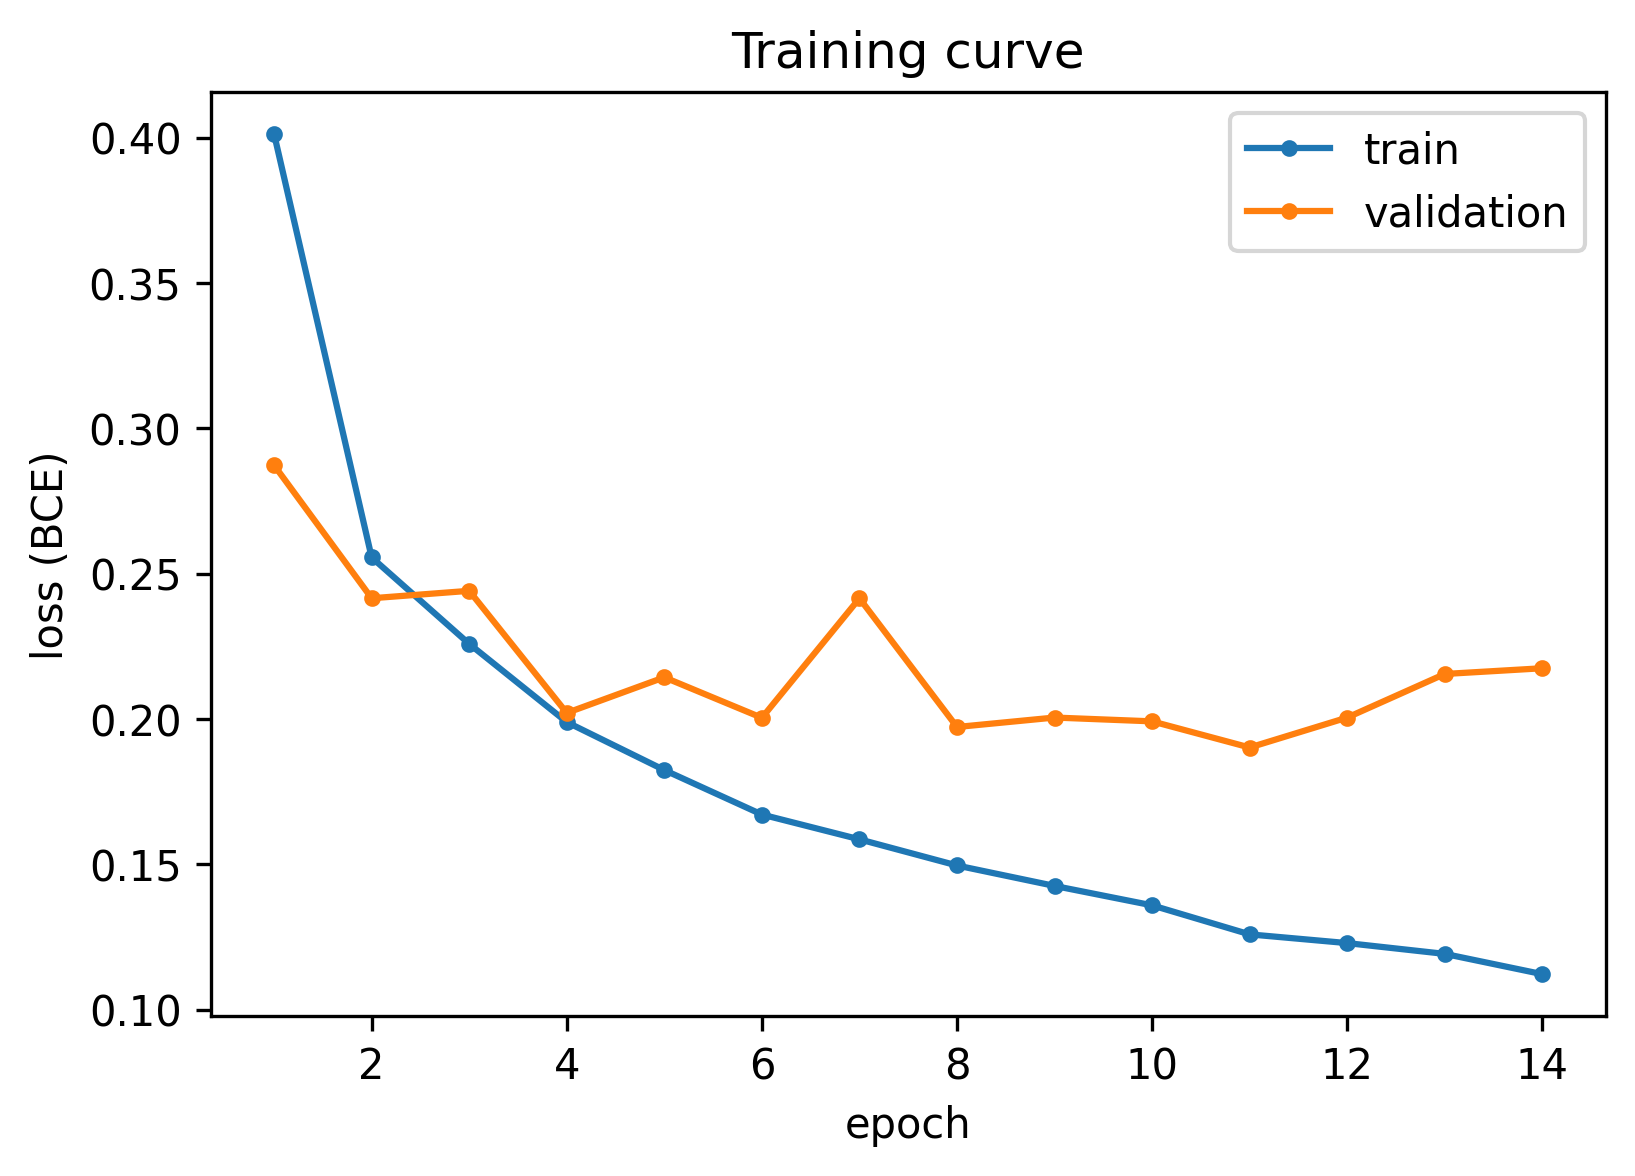

=== LSTM ===


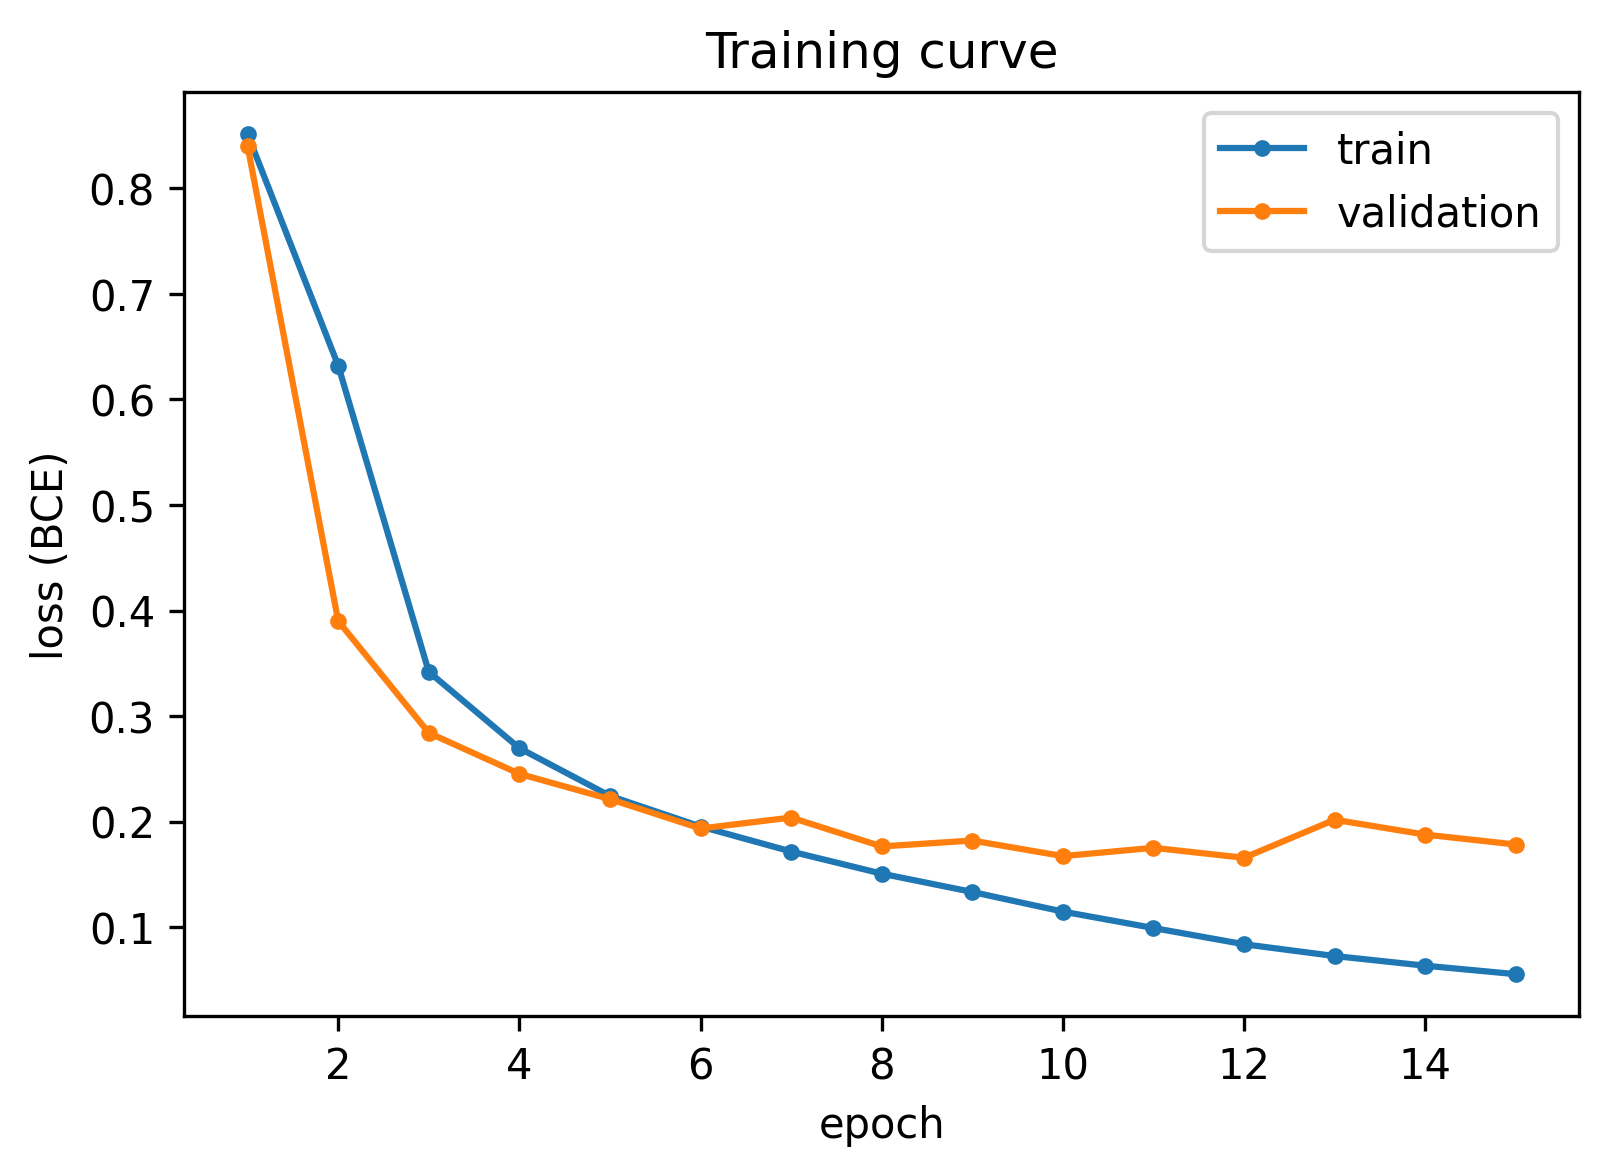

=== CNN-LSTM ===


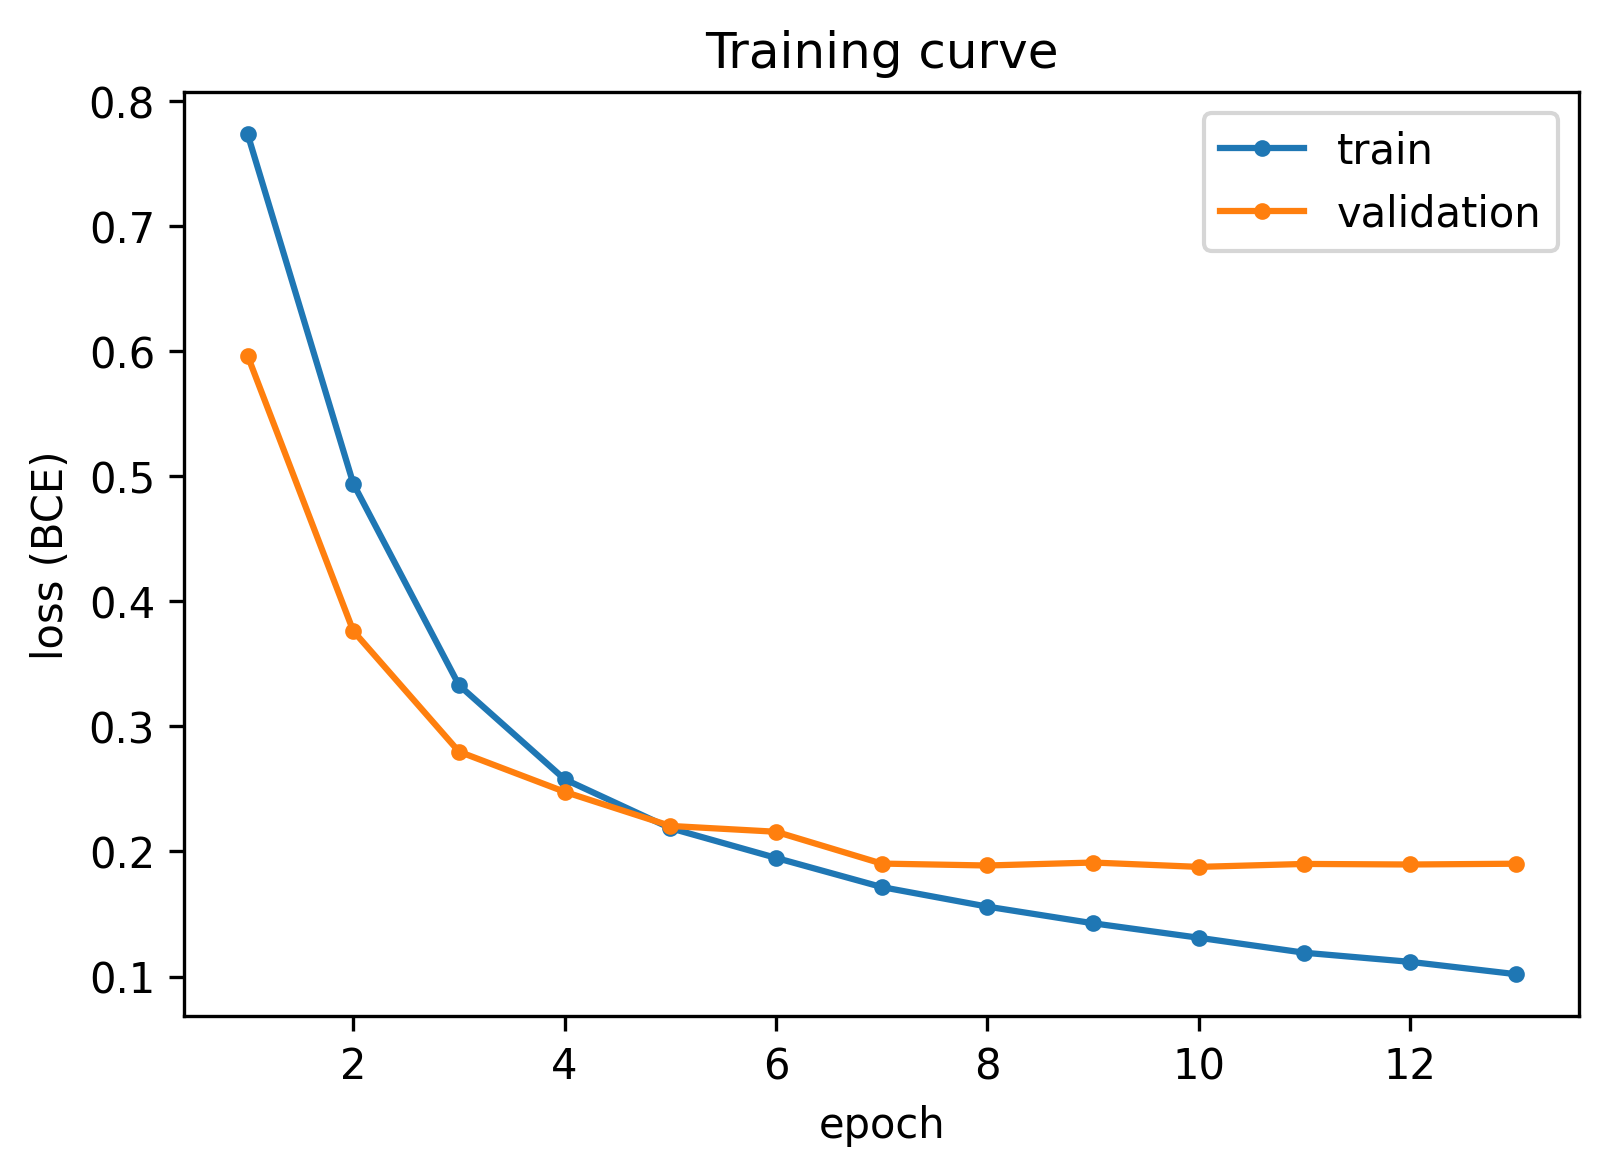

In [4]:
for name in ["CNN", "LSTM", "CNN-LSTM"]:
    p = TRAINING_CURVES_DIR / f"{name}_mendeley.png"
    if p.exists():
        print(f"=== {name} ===")
        display(Image(filename=str(p)))

## 4. Best DL model — confusion matrix & ROC

best DL model: LSTM


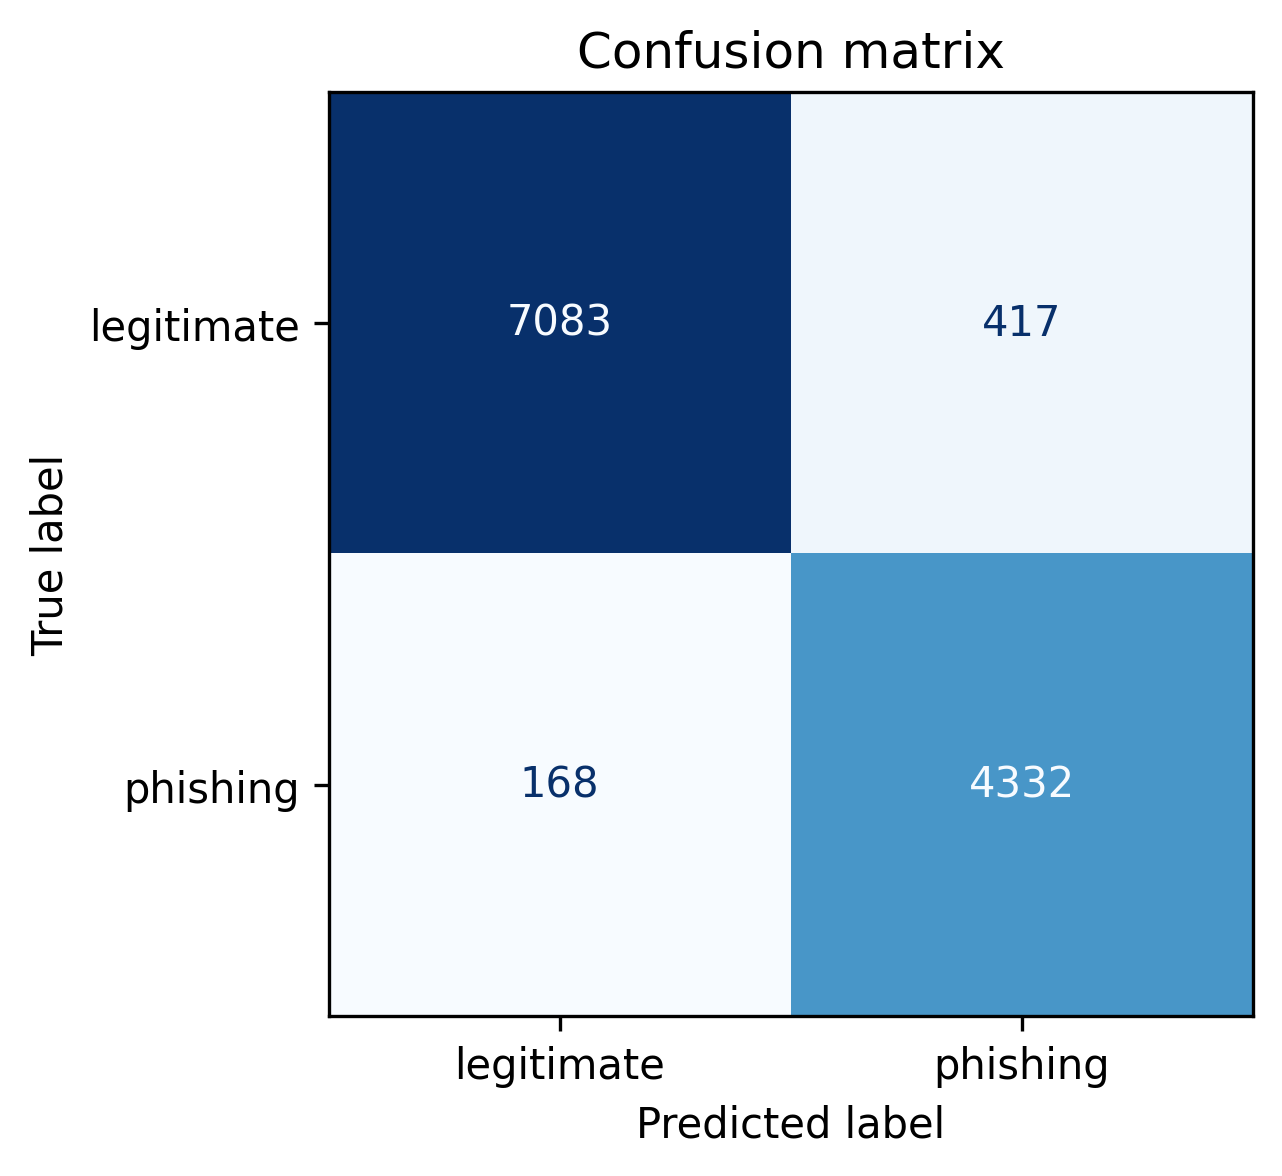

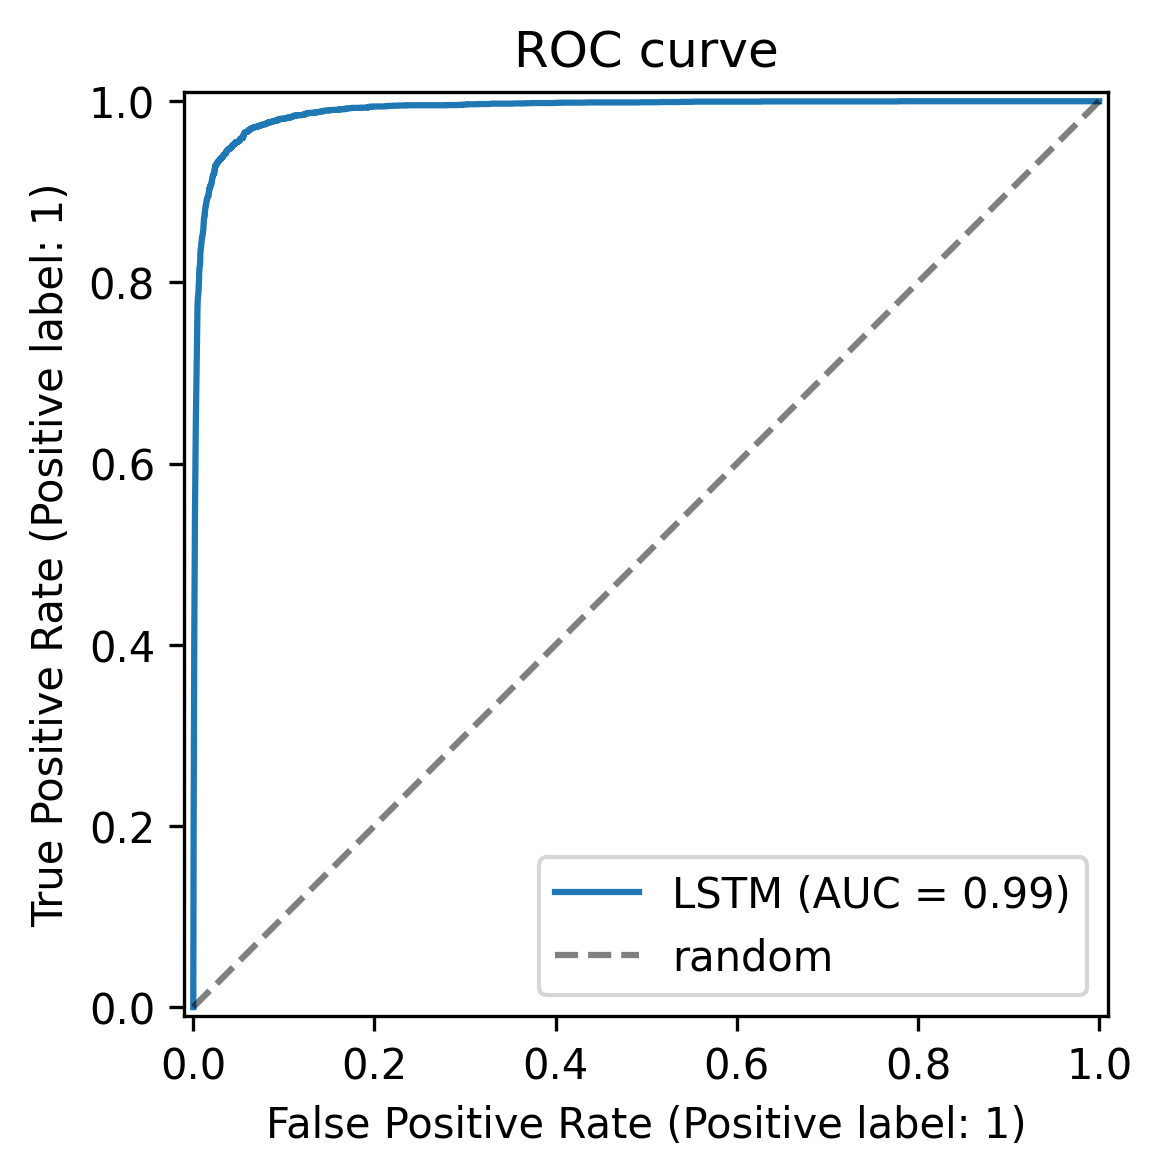

In [5]:
best = dl.sort_values("f1", ascending=False).iloc[0]["model"]
print("best DL model:", best)
for folder in (CONFUSION_MATRICES_DIR, ROC_CURVES_DIR):
    p = folder / f"{best}_mendeley.png"
    if p.exists():
        display(Image(filename=str(p)))

## 5. Deep Learning vs. best classical (Mendeley)

The key comparison: does learning from raw characters beat hand-crafted URL features?

,model,f1,auc_roc,type
0,LSTM,0.9367,0.9905,deep
1,CNN-LSTM,0.9316,0.9876,deep
2,CNN,0.9227,0.9871,deep
3,XGBoost,0.8571,0.9595,classical
4,CatBoost,0.8571,0.9587,classical
5,RandomForest,0.8531,0.9556,classical
6,DecisionTree,0.8218,0.8865,classical
7,SVM,0.8175,0.9374,classical
8,LogisticRegression,0.7443,0.8811,classical


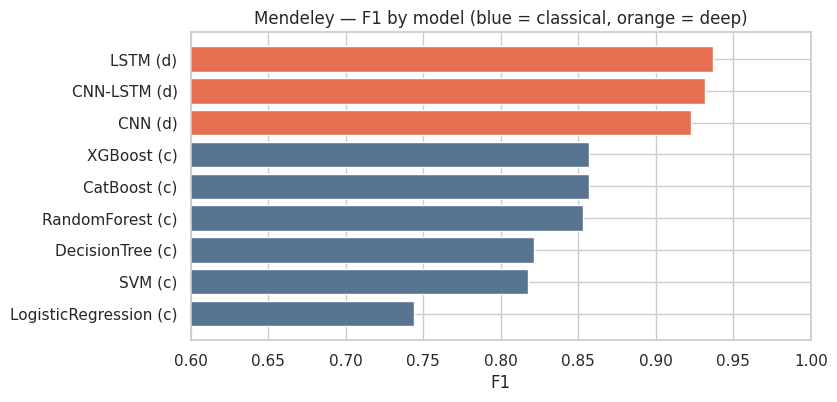

In [6]:
ml = pd.read_csv(METRICS_ML_CSV)
ml_men = ml[ml["dataset"] == "mendeley"][["model", "f1", "auc_roc"]].assign(type="classical")
dl_men = dl[dl["dataset"] == "mendeley"][["model", "f1", "auc_roc"]].assign(type="deep")
combined = pd.concat([ml_men, dl_men], ignore_index=True).sort_values("f1", ascending=False)
display(combined.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 4))
colors = combined["type"].map({"classical": "#577590", "deep": "#e76f51"})
ax.barh(combined["model"] + " (" + combined["type"].str[0] + ")", combined["f1"], color=colors)
ax.set_xlabel("F1"); ax.set_xlim(0.6, 1.0)
ax.set_title("Mendeley — F1 by model (blue = classical, orange = deep)")
ax.invert_yaxis()
plt.show()

## 6. Exit criterion

`metrics_dl.csv` holds the CNN / LSTM / CNN-LSTM results on Mendeley, each with a
confusion matrix, ROC, and training curve; manifests record GPU use, parameter
counts, epochs trained, and training time. Next: Phase 5 (DistilBERT) — optional.